# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name:** Ahmet Emre Bingöl  
**Student ID:** 2021403162

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors — such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers — affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | — |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **— (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [2]:
# Load the dataset
df = pd.read_csv('data/electrical_grid_stability.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Explore: shape, dtypes, head, missing values, describe, value_counts
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
display(df.describe())
print("\nTarget variable (stabf) value counts:")
print(df['stabf'].value_counts())

Shape: (10000, 14)

Data Types:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

First 5 rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



Missing values per column:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Descriptive statistics:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403



Target variable (stabf) value counts:
stabf
unstable    6380
stable      3620
Name: count, dtype: int64


---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [4]:
# Feature engineering
df['is_unstable'] = (df['stabf'] == 'unstable').astype(int)
df['total_reaction_time'] = df['tau1'] + df['tau2'] + df['tau3'] + df['tau4']
df['power_imbalance'] = df['p1'] + df['p2'] + df['p3'] + df['p4']
df['avg_elasticity'] = df[['g1', 'g2', 'g3', 'g4']].mean(axis=1)

print("New columns added:")
print(df[['is_unstable', 'total_reaction_time', 'power_imbalance', 'avg_elasticity']].head())

New columns added:


   is_unstable  total_reaction_time  power_imbalance  avg_elasticity
0            1            24.200725    -2.886580e-15        0.838878
1            0            18.623519    -6.661338e-16        0.654938
2            1            22.081132     0.000000e+00        0.469757
3            1            15.213218    -9.992007e-16        0.678763
4            1            25.544216     4.996004e-15        0.682607


In [5]:
# Print class balance
counts = df['stabf'].value_counts()
percentages = df['stabf'].value_counts(normalize=True) * 100

balance = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
print("Class Balance:")
print(balance)

Class Balance:
          Count  Percentage (%)
stabf                          
unstable   6380            63.8
stable     3620            36.2


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids — compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [6]:
# Grouped means by stabf
feats12 = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
grouped_means = df.groupby('stabf')[feats12].mean().T
grouped_means.columns.name = None
grouped_means['difference'] = (grouped_means['unstable'] - grouped_means['stable']).abs()
grouped_means_sorted = grouped_means.sort_values('difference', ascending=False)

print("Mean of each feature grouped by stability class (sorted by absolute difference):")
display(grouped_means_sorted.round(4))
print("\nFeatures that differ most: tau1, tau2, tau3, tau4 (reaction times) and g1, g2, g3, g4 (elasticity coefficients).")
print("Power features (p1-p4) show almost no difference between classes.")

Mean of each feature grouped by stability class (sorted by absolute difference):


,stable,unstable,difference
tau2,4.3534,5.7588,1.4054
tau4,4.3785,5.7445,1.3660
tau3,4.3854,5.7406,1.3552
tau1,4.3948,5.7352,1.3404
g3,0.4406,0.5729,0.1323
g2,0.4459,0.5699,0.1240
g4,0.4504,0.5673,0.1169
g1,0.4530,0.5658,0.1128
p4,-1.2369,-1.2574,0.0205
p1,3.7401,3.7556,0.0156



Features that differ most: tau1, tau2, tau3, tau4 (reaction times) and g1, g2, g3, g4 (elasticity coefficients).
Power features (p1-p4) show almost no difference between classes.


In [7]:
# Correlation with stab — identify top 3
corr_with_stab = df[feats12].corrwith(df['stab']).abs().sort_values(ascending=False)
print("Absolute correlation of each feature with 'stab' (continuous stability measure):")
print(corr_with_stab.round(4))
print(f"\nTop 3 features with highest absolute correlation:")
print(corr_with_stab.head(3).index.tolist())

Absolute correlation of each feature with 'stab' (continuous stability measure):
g3      0.3082
g2      0.2936
tau2    0.2910
g1      0.2828
tau3    0.2807
g4      0.2792
tau4    0.2786
tau1    0.2758
p4      0.0208
p1      0.0103
p2      0.0063
p3      0.0033
dtype: float64

Top 3 features with highest absolute correlation:
['g3', 'g2', 'tau2']


In [8]:
# Unstable grids: tau1 range and mean
unstable_df = df[df['stabf'] == 'unstable']
tau1_min = unstable_df['tau1'].min()
tau1_max = unstable_df['tau1'].max()
tau1_mean = unstable_df['tau1'].mean()

print(f"Unstable grids — tau1 (producer reaction time):")
print(f"  Min:  {tau1_min:.4f} seconds")
print(f"  Max:  {tau1_max:.4f} seconds")
print(f"  Mean: {tau1_mean:.4f} seconds")

Unstable grids — tau1 (producer reaction time):
  Min:  0.5013 seconds
  Max:  9.9995 seconds
  Mean: 5.7352 seconds


In [ ]:
# Compare g1 between stable and unstable
g1_stats = df.groupby('stabf')['g1'].agg(['mean', 'std']).round(4)
print("g1 (producer elasticity) statistics by stability class:")
display(g1_stats)
print("\nUnstable grids have a notably higher mean g1 (0.566) vs stable (0.453),")
print("suggesting higher producer price elasticity is associated with instability.")
print("However, the standard deviations are similar (~0.27 for both groups),")
print("indicating substantial overlap between the two distributions.")

---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

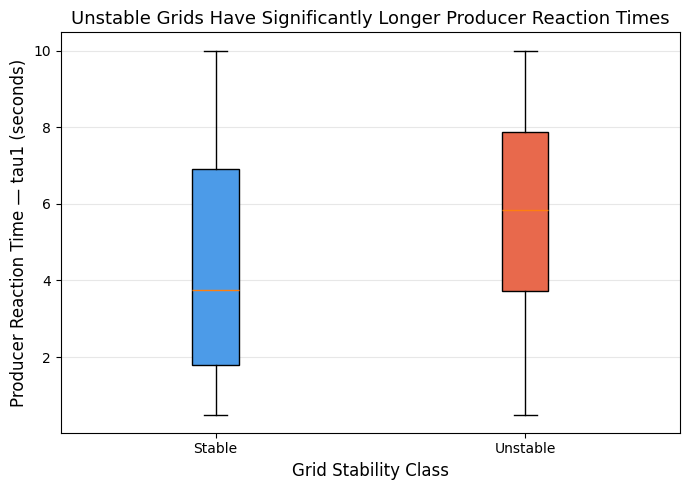

In [10]:
# (a) Boxplot of tau1 by stabf
fig, ax = plt.subplots(figsize=(7, 5))

stable_tau1 = df[df['stabf'] == 'stable']['tau1']
unstable_tau1 = df[df['stabf'] == 'unstable']['tau1']

bp = ax.boxplot([stable_tau1, unstable_tau1],
                patch_artist=True,
                labels=['Stable', 'Unstable'])

bp['boxes'][0].set_facecolor('#4C9BE8')
bp['boxes'][1].set_facecolor('#E8694C')

ax.set_xlabel('Grid Stability Class', fontsize=12)
ax.set_ylabel('Producer Reaction Time — tau1 (seconds)', fontsize=12)
ax.set_title('Unstable Grids Have Significantly Longer Producer Reaction Times', fontsize=13)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

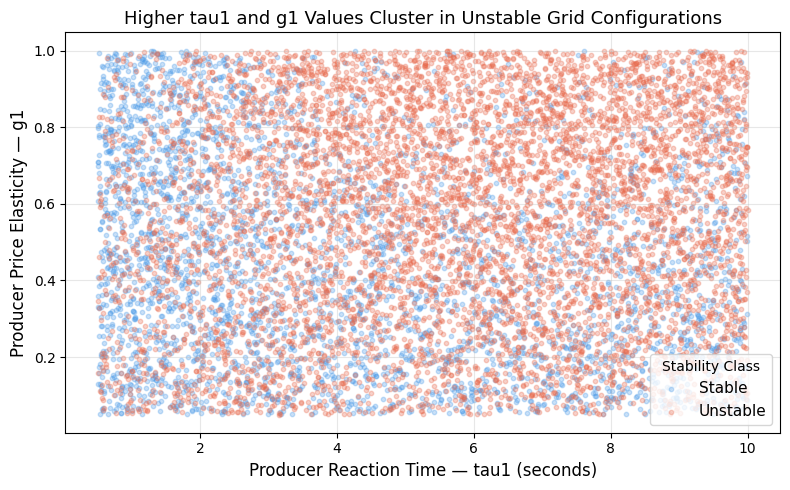

In [11]:
# (b) Scatter plot of tau1 vs g1, colored by stabf
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'stable': '#4C9BE8', 'unstable': '#E8694C'}
for label, group in df.groupby('stabf'):
    ax.scatter(group['tau1'], group['g1'],
               c=colors[label], label=label.capitalize(),
               alpha=0.3, s=10)

ax.set_xlabel('Producer Reaction Time — tau1 (seconds)', fontsize=12)
ax.set_ylabel('Producer Price Elasticity — g1', fontsize=12)
ax.set_title('Higher tau1 and g1 Values Cluster in Unstable Grid Configurations', fontsize=13)
ax.legend(title='Stability Class', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# (c) Correlation heatmap of 12 original features
corr_matrix = df[feats12].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})

ax.set_title('Correlation Heatmap of 12 Original Grid Features', fontsize=13)
plt.tight_layout()
plt.show()

---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [ ]:
# Z-scores for tau1
z_scores = np.abs(stats.zscore(df['tau1']))
outliers = df[z_scores > 2]
print(f"Total samples with |z-score| > 2 for tau1: {len(outliers)}")
print(f"\nFirst few outlier rows:")
display(outliers[['tau1', 'stabf']].head(10))

print("\nNote: tau1 follows a near-uniform distribution over [0.5, 10].")
print(f"With std ≈ {df['tau1'].std():.2f}, the most extreme values yield |z| ≈ {(df['tau1'].max() - df['tau1'].mean()) / df['tau1'].std():.2f},")
print("which is below the threshold of 2. Hence zero outliers — expected for uniformly distributed data.")

In [14]:
# Two-sample t-test: tau1 stable vs unstable
tau1_stable = df[df['stabf'] == 'stable']['tau1']
tau1_unstable = df[df['stabf'] == 'unstable']['tau1']

t_stat, p_value = stats.ttest_ind(tau1_stable, tau1_unstable)

print(f"Stable   — tau1 mean: {tau1_stable.mean():.4f}")
print(f"Unstable — tau1 mean: {tau1_unstable.mean():.4f}")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6e}")

Stable   — tau1 mean: 4.3948
Unstable — tau1 mean: 5.7352

t-statistic: -24.1635
p-value:     2.028320e-125


### Interpretation

**H0:** The mean tau1 of stable grids equals the mean tau1 of unstable grids (μ_stable = μ_unstable).  
**H1:** The mean tau1 differs between stable and unstable grids (μ_stable ≠ μ_unstable).  
**Result:** The p-value is far below 0.05, so we reject H0. There is a statistically significant difference in producer reaction times between stable and unstable grids.

**Most predictive feature:** `g3` has the highest absolute correlation with `stab` (r ≈ 0.308), followed closely by `g2` (0.294) and `tau2` (0.291). The differences among the top features are small, meaning several features are nearly equally predictive. Overall, the elasticity coefficients (g1–g4) and reaction times (tau1–tau4) are the strongest predictors, while power features (p1–p4) show negligible correlation. `g3` stands out marginally as the single most predictive feature by correlation magnitude.

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` — **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [15]:
# Define X and y, split, scale
X = df[feats12]
y = df['is_unstable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"Train class distribution: {y_train.value_counts().to_dict()}")
print(f"Test  class distribution: {y_test.value_counts().to_dict()}")

X_train: (8000, 12), X_test: (2000, 12)


y_train: (8000,), y_test: (2000,)
Train class distribution: {1: 5104, 0: 2896}
Test  class distribution: {1: 1276, 0: 724}


In [16]:
# Train, predict, evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=== Model Performance (Logistic Regression) ===")
print(f"Accuracy:             {acc:.4f}")
print(f"Precision (unstable): {precision:.4f}")
print(f"Recall    (unstable): {recall:.4f}")
print(f"F1 Score  (unstable): {f1:.4f}")

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                     index=['Actual Stable', 'Actual Unstable'],
                     columns=['Predicted Stable', 'Predicted Unstable'])
display(cm_df)

=== Model Performance (Logistic Regression) ===
Accuracy:             0.8200
Precision (unstable): 0.8408
Recall    (unstable): 0.8856
F1 Score  (unstable): 0.8626

=== Confusion Matrix ===


,Predicted Stable,Predicted Unstable
Actual Stable,510,214
Actual Unstable,146,1130


---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

A **False Stable** error is far more dangerous: if the model predicts stability when the grid is actually unstable, operators take no protective action, potentially leading to blackouts, cascading failures, and equipment damage. Our confusion matrix shows **146 such cases** — 146 unstable configurations misclassified as stable, each representing a missed risk. A **False Unstable** error (214 cases), by contrast, triggers an unnecessary intervention — costly and inconvenient, but not catastrophic. Therefore, **recall** for the "unstable" class should be prioritized, because minimizing missed instabilities (false negatives) is critical to grid safety, even at the cost of some false alarms.

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

Correlation only shows that two variables tend to move together — it does not tell us that one causes the other. Causation requires evidence of a directional mechanism, ideally through controlled experimentation. In this dataset, the observed correlation between tau1 and instability could be explained by a confounding variable: for example, **grid load level**. Under heavy load conditions, the producer may be operating near its physical limits, which simultaneously slows its response time (increases tau1) and increases the risk of instability due to insufficient reserve capacity. In this case, grid load would be the true driver of both tau1 and instability, making their correlation spurious rather than causal.

---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr